In [12]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

# 1. Iniciando o Spark com a configuração de rede correta
spark = SparkSession.builder \
    .appName("Transformacao_Gold_Adzuna") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://host.docker.internal:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "admin1234") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("Lendo dados limpos da Camada Silver (Parquet)...")
caminho_silver = "s3a://radar-sp/silver/vagas"
df_silver = spark.read.parquet(caminho_silver)

print(f"Total de registros para analisar: {df_silver.count()}")

Lendo dados limpos da Camada Silver (Parquet)...
Total de registros para analisar: 18


In [13]:
print("Extraindo ferramentas das descrições...")

# Lista das ferramentas do nosso radar
ferramentas_tech = [
    "python", "sql", "spark", "airflow", "docker", 
    "kubernetes", "aws", "azure", "gcp", "postgresql", 
    "kafka", "databricks", "snowflake" ,"IA","Delta Lake","Lakehouse","medallion"
]

df_gold = df_silver

# Loop para criar uma coluna Verdadeiro/Falso para cada ferramenta
for ferramenta in ferramentas_tech:
    # O \\b garante a busca exata da palavra
    padrao_regex = f"\\b{ferramenta}\\b"
    
    df_gold = df_gold.withColumn(
        f"req_{ferramenta}",
        when(col("descricao_padronizada").rlike(padrao_regex), True).otherwise(False)
    )

# Mostrando o resultado
df_gold.select("titulo_padronizado", "req_python", "req_sql", "req_spark", "req_airflow").show(10, truncate=False)

Extraindo ferramentas das descrições...
+-------------------------------------------+----------+-------+---------+-----------+
|titulo_padronizado                         |req_python|req_sql|req_spark|req_airflow|
+-------------------------------------------+----------+-------+---------+-----------+
|data engineer                              |false     |false  |false    |false      |
|lead data engineer                         |false     |false  |false    |false      |
|data engineer - data foundry engineer      |false     |false  |false    |false      |
|sr. data analytics engineer                |false     |false  |false    |false      |
|kdb/q developer – time series data engineer|false     |false  |false    |false      |
|data engineer                              |false     |false  |false    |false      |
|data engineer                              |false     |false  |false    |false      |
|data engineer                              |false     |true   |false    |false      |
|se

In [14]:
caminho_gold = "s3a://radar-sp/gold/vagas_features"

print("Salvando tabela final na Camada Gold...")

# Salvando no MinIO em formato Parquet
df_gold.write.mode("overwrite").parquet(caminho_gold)

print("✅ TASK-12 Concluída! Base Gold pronta para os dashboards.")

Salvando tabela final na Camada Gold...
✅ TASK-12 Concluída! Base Gold pronta para os dashboards.


In [15]:
import pyspark.sql.functions as F

print("Criando a regra de Senioridade a partir dos títulos das vagas...")

# Vamos classificar a vaga procurando abreviações e termos chave no título
df_senioridade = df_gold.withColumn(
    "nivel_experiencia",
    F.when(F.col("titulo_padronizado").rlike(r"\b(jr|junior|júnior)\b"), "Júnior")
    .when(F.col("titulo_padronizado").rlike(r"\b(pl|pleno)\b"), "Pleno")
    .when(F.col("titulo_padronizado").rlike(r"\b(sr|senior|sênior|especialista)\b"), "Sênior")
    .otherwise("Não Especificado")
)

df_senioridade.select("titulo_padronizado", "nivel_experiencia").show(10, truncate=False)

Criando a regra de Senioridade a partir dos títulos das vagas...
+-------------------------------------------+-----------------+
|titulo_padronizado                         |nivel_experiencia|
+-------------------------------------------+-----------------+
|data engineer                              |Não Especificado |
|lead data engineer                         |Não Especificado |
|data engineer - data foundry engineer      |Não Especificado |
|sr. data analytics engineer                |Sênior           |
|kdb/q developer – time series data engineer|Não Especificado |
|data engineer                              |Não Especificado |
|data engineer                              |Não Especificado |
|data engineer                              |Não Especificado |
|senior data engineer                       |Sênior           |
|data engineer                              |Não Especificado |
+-------------------------------------------+-----------------+
only showing top 10 rows



In [17]:
print("Agregando os dados: Contando ferramentas por nível de experiência...")

# Como as colunas 'req_' são True/False, nós as convertemos para Inteiro (1 ou 0) para podermos somar
expressoes_soma = [
    F.sum(F.col(f"req_{ferramenta}").cast("int")).alias(f"total_{ferramenta}")
    for ferramenta in ferramentas_tech
]

# O clássico GROUP BY do SQL, mas na sintaxe PySpark
df_agregado = df_senioridade.groupBy("nivel_experiencia").agg(*expressoes_soma)

# Mostrando a visão final que vai alimentar os gráficos
df_agregado.show(truncate=False)

Agregando os dados: Contando ferramentas por nível de experiência...
+-----------------+------------+---------+-----------+-------------+------------+----------------+---------+-----------+---------+----------------+-----------+----------------+---------------+--------+----------------+---------------+---------------+
|nivel_experiencia|total_python|total_sql|total_spark|total_airflow|total_docker|total_kubernetes|total_aws|total_azure|total_gcp|total_postgresql|total_kafka|total_databricks|total_snowflake|total_IA|total_Delta Lake|total_Lakehouse|total_medallion|
+-----------------+------------+---------+-----------+-------------+------------+----------------+---------+-----------+---------+----------------+-----------+----------------+---------------+--------+----------------+---------------+---------------+
|Não Especificado |0           |3        |0          |0            |0           |0               |0        |4          |1        |0               |0          |2               |0 

In [18]:
caminho_gold_agg = "s3a://radar-sp/gold/mart_ferramentas_senioridade"

print("Salvando a tabela analítica agregada (Data Mart)...")

df_agregado.write.mode("overwrite").parquet(caminho_gold_agg)

print("✅ TASK-13 Concluída! Cubo de dados gerado com sucesso.")

Salvando a tabela analítica agregada (Data Mart)...
✅ TASK-13 Concluída! Cubo de dados gerado com sucesso.


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

# 1. Iniciando o Spark
spark = SparkSession.builder \
    .appName("Visualizacao_Gold_Adzuna") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://host.docker.internal:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "admin1234") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("Puxando o Data Mart da Camada Gold...")
caminho_gold_agg = "s3a://radar-sp/gold/mart_ferramentas_senioridade"

# Lendo o Parquet com Spark e imediatamente convertendo para Pandas
df_spark = spark.read.parquet(caminho_gold_agg)
df_pandas = df_spark.toPandas()

display(df_pandas.head())

Puxando o Data Mart da Camada Gold...


,nivel_experiencia,total_python,total_sql,total_spark,total_airflow,total_docker,total_kubernetes,total_aws,total_azure,total_gcp,total_postgresql,total_kafka,total_databricks,total_snowflake,total_IA,total_Delta Lake,total_Lakehouse,total_medallion
0,Não Especificado,0,3,0,0,0,0,0,4,1,0,0,2,0,0,0,0,4
1,Sênior,1,1,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0


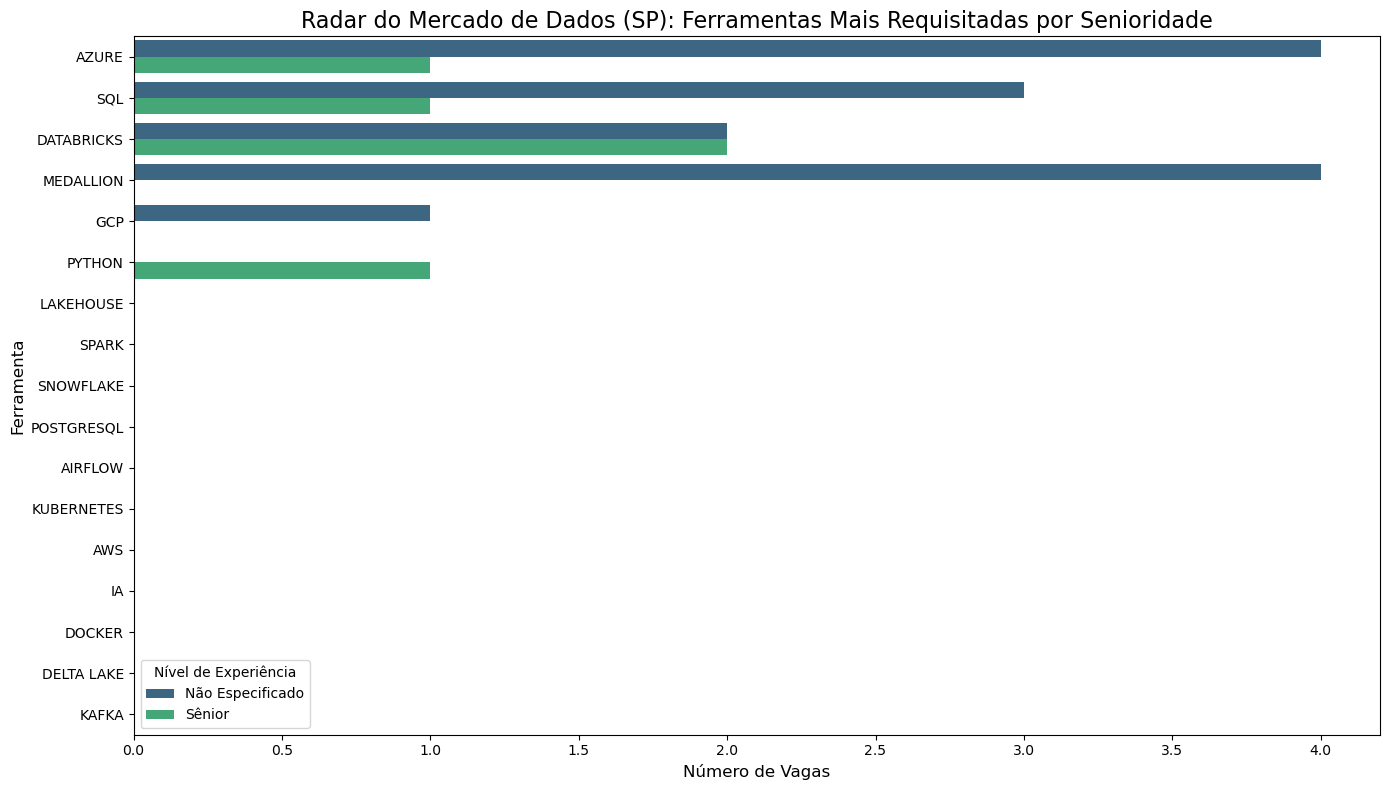

In [20]:
# Despivotando os dados para o formato ideal do Seaborn e Tableau
df_melted = df_pandas.melt(
    id_vars=['nivel_experiencia'], 
    var_name='ferramenta', 
    value_name='quantidade_vagas'
)

# Limpando o nome da ferramenta (tirando o 'total_' da string)
df_melted['ferramenta'] = df_melted['ferramenta'].str.replace('total_', '').str.upper()

# Ordenando pelas ferramentas mais pedidas no geral
ordem_ferramentas = df_melted.groupby('ferramenta')['quantidade_vagas'].sum().sort_values(ascending=False).index

# Plotando o Gráfico
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_melted, 
    x='quantidade_vagas', 
    y='ferramenta', 
    hue='nivel_experiencia',
    order=ordem_ferramentas,
    palette='viridis'
)

plt.title('Radar do Mercado de Dados (SP): Ferramentas Mais Requisitadas por Senioridade', fontsize=16)
plt.xlabel('Número de Vagas', fontsize=12)
plt.ylabel('Ferramenta', fontsize=12)
plt.legend(title='Nível de Experiência')
plt.tight_layout()
plt.show()